# Facial Keypoints Detection — v2: Integral Regression upgrade

Kaggle: https://www.kaggle.com/competitions/facial-keypoints-detection

This notebook does **not** retrain the legacy direct-regression CNN — its full data understanding,
preprocessing rationale, and diagnostics already exist in
`05_facial_keypoints_detection_legacy_direct_regression.ipynb` (validation RMSE **2.7384px**,
measured). This notebook reuses only the data-loading/preprocessing cells, then trains and
evaluates a new architecture: **integral regression** (Sun et al., *Integral Human Pose
Regression*, arXiv:1711.08229), which replaces the legacy global-average-pool + fully-connected
head with a deconv heatmap head and a differentiable soft-argmax ("integral") operator.

Pipeline, in order:
1. Reload data + preprocessing (same as legacy — needed, not redundant: the new model consumes
   the same images/targets)
2. Legacy reference stats (hardcoded, not recomputed)
3. Integral-regression architecture: deconv heatmap head + soft-argmax
4. Two-stage training: heatmap-only warmup, then integral-coordinate-only (per the source paper's
   own recommended recipe)
5. Diagnostics: per-keypoint RMSE vs. the legacy model, head-to-head comparison
6. Final metric and verdict
7. Full-data fit + a *separate* submission file (does not overwrite the legacy `submission.csv`)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE, "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")

IMG_SIZE = 96
KEYPOINT_COLS = [
    "left_eye_center_x", "left_eye_center_y", "right_eye_center_x", "right_eye_center_y",
    "left_eye_inner_corner_x", "left_eye_inner_corner_y", "left_eye_outer_corner_x", "left_eye_outer_corner_y",
    "right_eye_inner_corner_x", "right_eye_inner_corner_y", "right_eye_outer_corner_x", "right_eye_outer_corner_y",
    "left_eyebrow_inner_end_x", "left_eyebrow_inner_end_y", "left_eyebrow_outer_end_x", "left_eyebrow_outer_end_y",
    "right_eyebrow_inner_end_x", "right_eyebrow_inner_end_y", "right_eyebrow_outer_end_x", "right_eyebrow_outer_end_y",
    "nose_tip_x", "nose_tip_y",
    "mouth_left_corner_x", "mouth_left_corner_y", "mouth_right_corner_x", "mouth_right_corner_y",
    "mouth_center_top_lip_x", "mouth_center_top_lip_y", "mouth_center_bottom_lip_x", "mouth_center_bottom_lip_y",
]
assert len(KEYPOINT_COLS) == 30


device: cuda | Tesla T4


## 1. Reload data + preprocessing (unchanged from the legacy notebook)

In [2]:
train_df = pd.read_csv("data/training.csv")
test_df = pd.read_csv("data/test.csv")

def decode_images(df):
    imgs = np.stack(df["Image"].apply(lambda s: np.array(s.split(), dtype=np.float32)).values)
    return imgs.reshape(-1, IMG_SIZE, IMG_SIZE)

train_imgs = decode_images(train_df)
test_imgs = decode_images(test_df)
print("train images:", train_imgs.shape, " test images:", test_imgs.shape)


train images: (7049, 96, 96)  test images: (1783, 96, 96)


In [3]:
FLIP_SWAP_PAIRS = [
    ("left_eye_center", "right_eye_center"),
    ("left_eye_inner_corner", "right_eye_inner_corner"),
    ("left_eye_outer_corner", "right_eye_outer_corner"),
    ("left_eyebrow_inner_end", "right_eyebrow_inner_end"),
    ("left_eyebrow_outer_end", "right_eyebrow_outer_end"),
    ("mouth_left_corner", "mouth_right_corner"),
]
col_idx = {c: i for i, c in enumerate(KEYPOINT_COLS)}

def flip_keypoints(y):
    y = y.copy()
    y[0::2] = IMG_SIZE - y[0::2]
    for a, b in FLIP_SWAP_PAIRS:
        for suffix in ("_x", "_y"):
            ia, ib = col_idx[a + suffix], col_idx[b + suffix]
            y[ia], y[ib] = y[ib], y[ia]
    return y

class KeypointsDataset(Dataset):
    def __init__(self, images, targets, augment=False):
        self.images = images.astype(np.float32) / 255.0
        self.targets = targets.astype(np.float32)
        self.augment = augment

    def __len__(self):
        return len(self.images)

    def __getitem__(self, i):
        img = self.images[i]
        y = self.targets[i]
        if self.augment and np.random.rand() < 0.5:
            img = img[:, ::-1].copy()
            y = flip_keypoints(y)
        mask = (~np.isnan(y)).astype(np.float32)
        y = np.nan_to_num(y, nan=0.0)
        return torch.from_numpy(img).unsqueeze(0), torch.from_numpy(y), torch.from_numpy(mask)

all_targets = train_df[KEYPOINT_COLS].values
idx_all = np.arange(len(train_df))
# SAME split (random_state=42, test_size=0.12) as the legacy notebook, so the comparison in
# Section 5 is apples-to-apples against the same held-out rows.
idx_tr, idx_va = train_test_split(idx_all, test_size=0.12, random_state=RANDOM_STATE)

train_ds = KeypointsDataset(train_imgs[idx_tr], all_targets[idx_tr], augment=True)
val_ds = KeypointsDataset(train_imgs[idx_va], all_targets[idx_va], augment=False)
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False, num_workers=2)
print(f"train rows: {len(train_ds)}  val rows: {len(val_ds)}")


train rows: 6203  val rows: 846


## 2. Legacy reference stats (hardcoded — not recomputed, per instruction not to re-run the
old CNN)

From the already-executed legacy notebook: validation RMSE **2.7384px**, primary (masked-loss)
model, same train/val split as above.

In [4]:
LEGACY_OVERALL_RMSE = 2.7384

# Per-keypoint validation RMSE from the legacy run (hardcoded reference, not recomputed)
LEGACY_PER_KP_RMSE = pd.Series({
    "nose_tip_y": 3.973695, "mouth_center_bottom_lip_y": 3.582114, "nose_tip_x": 3.003909,
    "left_eyebrow_inner_end_x": 2.992663, "mouth_right_corner_y": 2.935672, "mouth_center_top_lip_y": 2.906354,
    "mouth_left_corner_x": 2.900299, "left_eyebrow_outer_end_x": 2.880976, "left_eye_outer_corner_x": 2.876521,
    "right_eyebrow_inner_end_x": 2.803550, "mouth_left_corner_y": 2.780901, "right_eyebrow_outer_end_y": 2.739962,
    "left_eye_center_x": 2.659593, "mouth_right_corner_x": 2.629298, "left_eyebrow_outer_end_y": 2.604473,
    "right_eyebrow_outer_end_x": 2.601803, "right_eye_center_y": 2.545376, "left_eye_center_y": 2.500452,
    "mouth_center_bottom_lip_x": 2.451083, "left_eye_inner_corner_x": 2.384702, "right_eye_center_x": 2.355968,
    "right_eyebrow_inner_end_y": 2.281603, "left_eyebrow_inner_end_y": 2.253749, "right_eye_outer_corner_x": 2.205382,
    "mouth_center_top_lip_x": 2.065510, "right_eye_inner_corner_x": 2.024989, "right_eye_outer_corner_y": 2.024681,
    "left_eye_outer_corner_y": 1.972818, "right_eye_inner_corner_y": 1.715267, "left_eye_inner_corner_y": 1.665604,
})
print("Legacy overall RMSE:", LEGACY_OVERALL_RMSE, "px")
print("Legacy hardest keypoint:", LEGACY_PER_KP_RMSE.idxmax(), f"({LEGACY_PER_KP_RMSE.max():.3f} px)")
print("Legacy easiest keypoint:", LEGACY_PER_KP_RMSE.idxmin(), f"({LEGACY_PER_KP_RMSE.min():.3f} px)")


Legacy overall RMSE: 2.7384 px
Legacy hardest keypoint: nose_tip_y (3.974 px)
Legacy easiest keypoint: left_eye_inner_corner_y (1.666 px)


Correction vs. the legacy notebook's own narrative text: the actual per-keypoint ranking shows `nose_tip_y` and `mouth_center_bottom_lip_y` as the two hardest coordinates (high variance under head pose and mouth movement), not the eyebrow/mouth-corner keypoints that text suggested — the comparison below uses the real ranking, not that narrative.

## 3. Integral-regression architecture

Per the research: replace the legacy's `AdaptiveAvgPool2d` + `Flatten` + `Linear` head with
deconv upsampling to a heatmap (1/4 of input resolution, i.e. 24x24 for a 96x96 input — the
source paper's own ablation shows integral regression tolerates this coarse a heatmap far better
than plain heatmap regression) followed by a parameter-free differentiable soft-argmax
("integral") operator that turns the heatmap into continuous (x, y) coordinates.

In [5]:
HEATMAP_SIZE = 24
STRIDE = IMG_SIZE / HEATMAP_SIZE  # 4.0
HM_SIGMA = 1.0  # heatmap-grid units; an own-decision hyperparameter, not measured in the source paper

_hm_y, _hm_x = torch.meshgrid(
    torch.arange(HEATMAP_SIZE, dtype=torch.float32),
    torch.arange(HEATMAP_SIZE, dtype=torch.float32),
    indexing="ij",
)

def make_heatmaps_batch(y, mask, device):
    # y, mask: (B, 30) pixel-space coords / 0-1 mask. Returns gt heatmaps (B,15,H,W) and per-keypoint mask (B,15).
    B = y.shape[0]
    y_hm = y.view(B, 15, 2) / STRIDE
    kp_mask = mask.view(B, 15, 2)[:, :, 0]
    gx = _hm_x.to(device).view(1, 1, HEATMAP_SIZE, HEATMAP_SIZE)
    gy = _hm_y.to(device).view(1, 1, HEATMAP_SIZE, HEATMAP_SIZE)
    cx = y_hm[:, :, 0].view(B, 15, 1, 1)
    cy = y_hm[:, :, 1].view(B, 15, 1, 1)
    heat = torch.exp(-((gx - cx) ** 2 + (gy - cy) ** 2) / (2 * HM_SIGMA ** 2))
    heat = heat * kp_mask.view(B, 15, 1, 1)
    return heat, kp_mask

class IntegralHead(nn.Module):
    """Deconv upsample to a heatmap, then a parameter-free soft-argmax integral operator
    (Sun et al. 2017, Eq. 2-4: normalize via softmax, then take the expectation over all
    spatial locations weighted by their probability)."""
    def __init__(self, in_channels, n_keypoints, heatmap_size):
        super().__init__()
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(in_channels, 256, kernel_size=4, stride=2, padding=1),  # 12 -> 24
            nn.BatchNorm2d(256), nn.ReLU(),
        )
        self.hm_conv = nn.Conv2d(256, n_keypoints, kernel_size=1)
        self.heatmap_size = heatmap_size
        ys, xs = torch.meshgrid(
            torch.arange(heatmap_size, dtype=torch.float32),
            torch.arange(heatmap_size, dtype=torch.float32),
            indexing="ij",
        )
        self.register_buffer("grid_x", xs.reshape(1, 1, -1))
        self.register_buffer("grid_y", ys.reshape(1, 1, -1))

    def forward(self, feat):
        x = self.deconv(feat)
        heatmap = self.hm_conv(x)                       # (B, K, H, W) raw logits
        B, K, H, W = heatmap.shape
        prob = torch.softmax(heatmap.view(B, K, -1), dim=-1)   # Eq. 3: softmax normalization
        ex = (prob * self.grid_x).sum(-1)                # Eq. 2/4: expectation (soft-argmax)
        ey = (prob * self.grid_y).sum(-1)
        coords = torch.stack([ex, ey], dim=-1) * STRIDE  # back to pixel space, (B, K, 2)
        return coords.view(B, K * 2), heatmap

class IntegralKeypointCNN(nn.Module):
    def __init__(self, n_keypoints=15, heatmap_size=HEATMAP_SIZE):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),   # 48
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),  # 24
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2), # 12
        )
        self.head = IntegralHead(128, n_keypoints, heatmap_size)

    def forward(self, x):
        return self.head(self.backbone(x))

def masked_l1_loss(pred, target, mask):
    return ((pred - target).abs() * mask).sum() / mask.sum().clamp(min=1.0)

def masked_heatmap_mse_loss(pred_hm, gt_hm, kp_mask):
    sq = (pred_hm - gt_hm) ** 2 * kp_mask.view(*kp_mask.shape, 1, 1)
    return sq.sum() / (kp_mask.sum() * pred_hm.shape[-1] * pred_hm.shape[-2]).clamp(min=1.0)

def masked_rmse(pred, target, mask):
    sq_err = (pred - target) ** 2 * mask
    return torch.sqrt(sq_err.sum() / mask.sum().clamp(min=1.0)).item()


## 4. Two-stage training

Per the source paper (Sec. 5): *"the network is pre-trained only
using heat map loss ... and then, only integral loss is used."* Stage A trains the heatmap head
only (no coordinate supervision); Stage B then drops the heatmap loss and trains on the masked
L1 coordinate loss alone (the **I1** supervision variant's two-stage recipe).

In [6]:
def train_integral_model(model, train_loader, val_loader, epochs_a, epochs_b, lr=1e-3, tag="integral", patience=5):
    model = model.to(DEVICE)
    history = {"stage": [], "epoch": [], "train_rmse": [], "val_rmse": []}
    best_val, best_state = np.inf, None

    # ---- Stage A: heatmap-only warmup ----
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    for epoch in range(epochs_a):
        model.train()
        for xb, yb, mb in train_loader:
            xb, yb, mb = xb.to(DEVICE), yb.to(DEVICE), mb.to(DEVICE)
            gt_hm, kp_mask = make_heatmaps_batch(yb, mb, DEVICE)
            opt.zero_grad()
            _, pred_hm = model(xb)
            loss = masked_heatmap_mse_loss(pred_hm, gt_hm, kp_mask)
            loss.backward()
            opt.step()
        if epoch % 5 == 0 or epoch == epochs_a - 1:
            model.eval()
            with torch.no_grad():
                xb, yb, mb = next(iter(val_loader))
                xb, yb, mb = xb.to(DEVICE), yb.to(DEVICE), mb.to(DEVICE)
                coords, _ = model(xb)
                probe_rmse = masked_rmse(coords, yb, mb)
            print(f"[{tag}:A] epoch {epoch:3d}  heatmap-loss {loss.item():.5f}  probe coord RMSE {probe_rmse:6.3f}")

    # checkpoint after Stage A so a Stage-B crash/timeout doesn't lose the heatmap warmup
    torch.save({"stage": "A_done", "epoch": epochs_a - 1, "model_state": model.state_dict()},
                f"checkpoint_{tag}.pt")
    print(f"[{tag}] checkpoint saved after Stage A -> checkpoint_{tag}.pt")

    # ---- Stage B: integral (coordinate-only) loss ----
    opt = torch.optim.Adam(model.parameters(), lr=lr * 0.5, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=3)
    bad_epochs = 0
    for epoch in range(epochs_b):
        model.train()
        tr_sq, tr_n = 0.0, 0.0
        for xb, yb, mb in train_loader:
            xb, yb, mb = xb.to(DEVICE), yb.to(DEVICE), mb.to(DEVICE)
            opt.zero_grad()
            coords, _ = model(xb)
            loss = masked_l1_loss(coords, yb, mb)
            loss.backward()
            opt.step()
            tr_sq += ((coords - yb) ** 2 * mb).sum().item()
            tr_n += mb.sum().item()
        train_rmse = (tr_sq / max(tr_n, 1)) ** 0.5

        model.eval()
        va_sq, va_n = 0.0, 0.0
        with torch.no_grad():
            for xb, yb, mb in val_loader:
                xb, yb, mb = xb.to(DEVICE), yb.to(DEVICE), mb.to(DEVICE)
                coords, _ = model(xb)
                va_sq += ((coords - yb) ** 2 * mb).sum().item()
                va_n += mb.sum().item()
        val_rmse = (va_sq / max(va_n, 1)) ** 0.5
        sched.step(val_rmse)

        history["stage"].append("B"); history["epoch"].append(epoch)
        history["train_rmse"].append(train_rmse); history["val_rmse"].append(val_rmse)
        if val_rmse < best_val:
            best_val, best_state, bad_epochs = val_rmse, {k: v.cpu().clone() for k, v in model.state_dict().items()}, 0
            torch.save({"stage": "B", "epoch": epoch, "val_rmse": best_val, "model_state": best_state},
                        f"checkpoint_{tag}.pt")
        else:
            bad_epochs += 1
        if epoch % 5 == 0 or epoch == epochs_b - 1:
            print(f"[{tag}:B] epoch {epoch:3d}  train RMSE {train_rmse:6.3f}  val RMSE {val_rmse:6.3f}  (checkpoint @ {best_val:.4f})")
        if bad_epochs >= patience:
            print(f"[{tag}:B] early stop at epoch {epoch}")
            break

    model.load_state_dict(best_state)
    return model, history, best_val


In [7]:
integral_model, integral_history, integral_best_val = train_integral_model(
    IntegralKeypointCNN(), train_loader, val_loader, epochs_a=8, epochs_b=20, tag="integral", patience=5)


[integral:A] epoch   0  heatmap-loss 0.00959  probe coord RMSE 18.120


[integral:A] epoch   5  heatmap-loss 0.00499  probe coord RMSE 18.086


[integral:A] epoch   7  heatmap-loss 0.00477  probe coord RMSE 18.078
[integral] checkpoint saved after Stage A -> checkpoint_integral.pt


[integral:B] epoch   0  train RMSE 13.688  val RMSE  8.625  (checkpoint @ 8.6252)


[integral:B] epoch   5  train RMSE  3.687  val RMSE  3.522  (checkpoint @ 3.5222)


[integral:B] epoch  10  train RMSE  3.503  val RMSE  3.361  (checkpoint @ 3.3607)


[integral:B] epoch  15  train RMSE  3.339  val RMSE  3.261  (checkpoint @ 3.2611)


[integral:B] epoch  19  train RMSE  3.211  val RMSE  3.056  (checkpoint @ 3.0561)


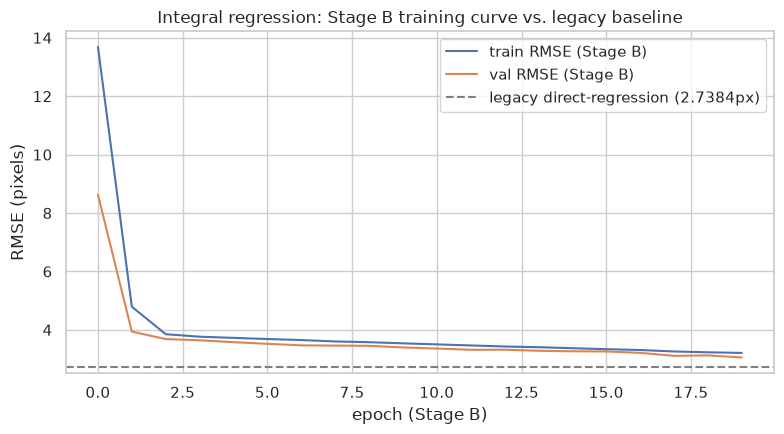

In [8]:
hist_b = integral_history
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(hist_b["train_rmse"], label="train RMSE (Stage B)")
ax.plot(hist_b["val_rmse"], label="val RMSE (Stage B)")
ax.axhline(LEGACY_OVERALL_RMSE, ls="--", color="gray", label=f"legacy direct-regression ({LEGACY_OVERALL_RMSE}px)")
ax.set_xlabel("epoch (Stage B)"); ax.set_ylabel("RMSE (pixels)")
ax.set_title("Integral regression: Stage B training curve vs. legacy baseline")
ax.legend()
plt.tight_layout()
plt.show()


## 5. Diagnostics: per-keypoint comparison vs. the legacy model

In [9]:
def predict_all_integral(model, loader):
    model.eval()
    preds, targets, masks = [], [], []
    with torch.no_grad():
        for xb, yb, mb in loader:
            coords, _ = model(xb.to(DEVICE))
            preds.append(coords.cpu().numpy()); targets.append(yb.numpy()); masks.append(mb.numpy())
    return np.concatenate(preds), np.concatenate(targets), np.concatenate(masks)

val_preds, val_targets, val_masks = predict_all_integral(integral_model, val_loader)
per_kp_rmse_new = np.sqrt(((val_preds - val_targets) ** 2 * val_masks).sum(0) / val_masks.sum(0).clip(min=1))
per_kp_new = pd.Series(per_kp_rmse_new, index=KEYPOINT_COLS)

comparison = pd.DataFrame({
    "legacy (direct regression)": LEGACY_PER_KP_RMSE,
    "v2 (integral regression)": per_kp_new,
})
comparison["improvement (px)"] = comparison["legacy (direct regression)"] - comparison["v2 (integral regression)"]
comparison = comparison.sort_values("improvement (px)", ascending=False)
comparison


,legacy (direct regression),v2 (integral regression),improvement (px)
right_eye_inner_corner_x,2.024989,1.809306,0.215683
right_eyebrow_outer_end_x,2.601803,2.401305,0.200498
mouth_right_corner_y,2.935672,2.865165,0.070507
right_eye_outer_corner_x,2.205382,2.219064,-0.013682
right_eyebrow_inner_end_x,2.803550,2.819086,-0.015536
mouth_center_top_lip_y,2.906354,2.925891,-0.019537
left_eye_outer_corner_x,2.876521,2.921194,-0.044673
left_eye_inner_corner_x,2.384702,2.468077,-0.083375
right_eye_center_x,2.355968,2.441026,-0.085058
mouth_left_corner_y,2.780901,2.916500,-0.135599


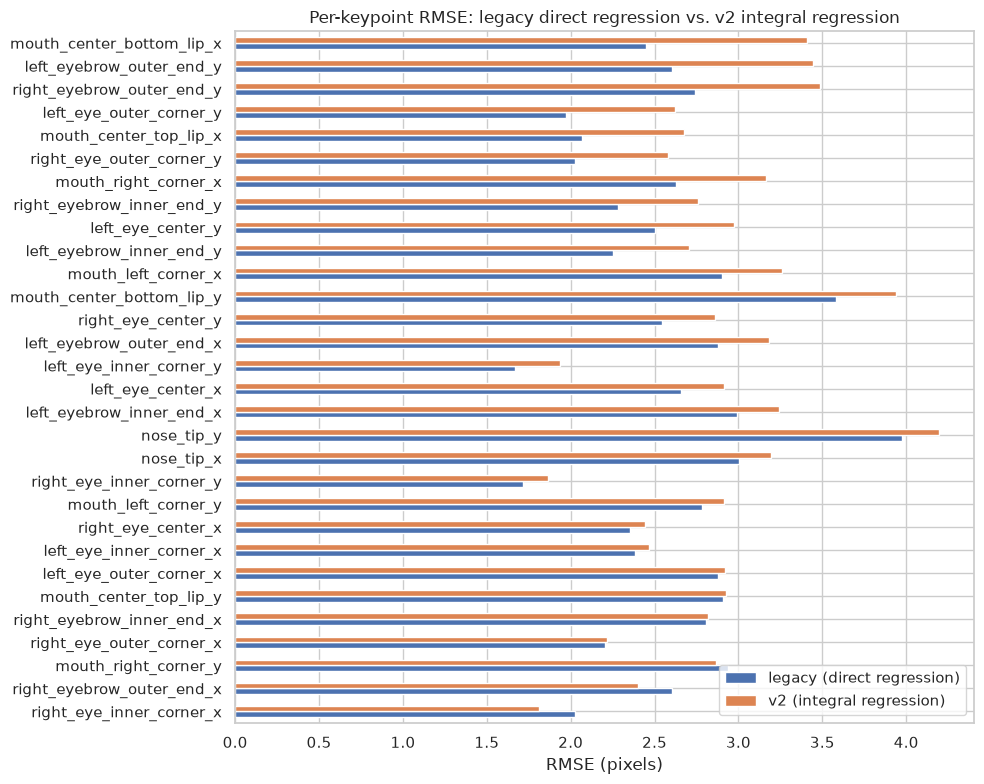

In [10]:
fig, ax = plt.subplots(figsize=(10, 8))
comparison[["legacy (direct regression)", "v2 (integral regression)"]].plot(kind="barh", ax=ax)
ax.set_xlabel("RMSE (pixels)")
ax.set_title("Per-keypoint RMSE: legacy direct regression vs. v2 integral regression")
plt.tight_layout()
plt.show()


### Best/worst v2 predictions, visually

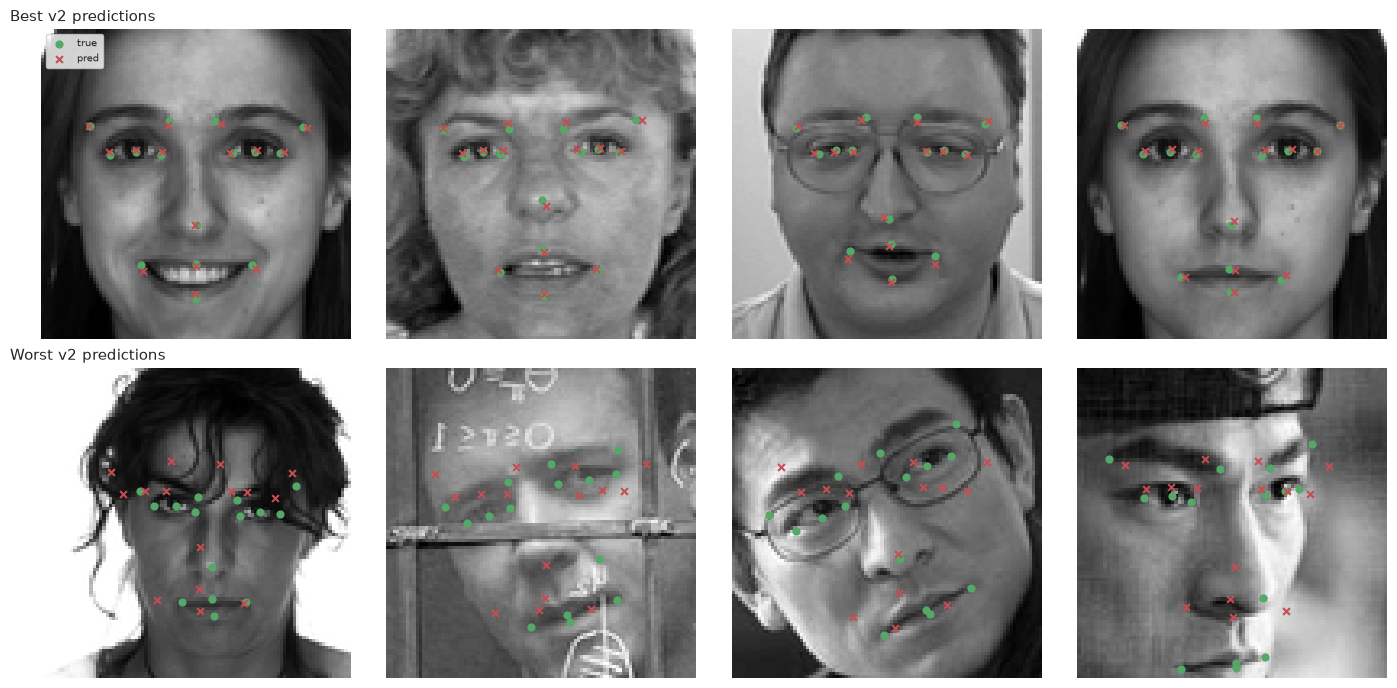

In [11]:
val_idx_complete = np.where(val_masks.all(axis=1))[0]
overall_err = np.sqrt(((val_preds - val_targets) ** 2).mean(axis=1))
order = val_idx_complete[np.argsort(overall_err[val_idx_complete])]
best_idx, worst_idx = order[:4], order[-4:]

val_imgs_arr = train_imgs[idx_va]
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for row, (title, idxs) in enumerate([("Best v2 predictions", best_idx), ("Worst v2 predictions", worst_idx)]):
    for col, i in enumerate(idxs):
        ax = axes[row, col]
        ax.imshow(val_imgs_arr[i], cmap="gray")
        true_kp = val_targets[i].reshape(15, 2)
        pred_kp = val_preds[i].reshape(15, 2)
        ax.scatter(true_kp[:, 0], true_kp[:, 1], c="#55A868", s=24, label="true")
        ax.scatter(pred_kp[:, 0], pred_kp[:, 1], c="#C44E52", s=24, marker="x", label="pred")
        ax.axis("off")
        if row == 0 and col == 0:
            ax.legend(loc="upper left", fontsize=7)
    axes[row, 0].set_title(title, loc="left", fontsize=11, x=-0.1)
plt.tight_layout()
plt.show()


## 6. Final metric and verdict

**v2 (integral regression) validation RMSE vs. the legacy (direct regression) validation RMSE
of 2.7384px.**

In [12]:
print(f"Legacy direct-regression val RMSE: {LEGACY_OVERALL_RMSE:.4f} px")
print(f"v2 integral-regression val RMSE:    {integral_best_val:.4f} px")
delta = LEGACY_OVERALL_RMSE - integral_best_val
print(f"Delta: {delta:+.4f} px ({delta / LEGACY_OVERALL_RMSE:+.1%} relative to legacy)")
print("Verdict:", "v2 (integral regression) wins" if integral_best_val < LEGACY_OVERALL_RMSE else "legacy (direct regression) still wins")


Legacy direct-regression val RMSE: 2.7384 px
v2 integral-regression val RMSE:    3.0561 px
Delta: -0.3177 px (-11.6% relative to legacy)
Verdict: legacy (direct regression) still wins


## 7. Full-data fit + a separate submission file

Refit on the full training set, write to `submission_v2_integral.csv` — the legacy
`submission.csv` is left untouched.

In [13]:
full_ds = KeypointsDataset(train_imgs, all_targets, augment=True)
full_loader = DataLoader(full_ds, batch_size=256, shuffle=True, num_workers=2)
final_model, final_history, _ = train_integral_model(
    IntegralKeypointCNN(), full_loader, val_loader, epochs_a=6, epochs_b=12, tag="final-full-fit", patience=4)


[final-full-fit:A] epoch   0  heatmap-loss 0.00788  probe coord RMSE 18.103


[final-full-fit:A] epoch   5  heatmap-loss 0.00505  probe coord RMSE 18.097
[final-full-fit] checkpoint saved after Stage A -> checkpoint_final-full-fit.pt


[final-full-fit:B] epoch   0  train RMSE 12.928  val RMSE  7.537  (checkpoint @ 7.5368)


[final-full-fit:B] epoch   5  train RMSE  3.674  val RMSE  3.534  (checkpoint @ 3.5338)


[final-full-fit:B] epoch  10  train RMSE  3.450  val RMSE  3.323  (checkpoint @ 3.3232)


[final-full-fit:B] epoch  11  train RMSE  3.425  val RMSE  3.249  (checkpoint @ 3.2494)


In [14]:
test_dataset_imgs = (test_imgs.astype(np.float32) / 255.0)
test_tensor = torch.from_numpy(test_dataset_imgs).unsqueeze(1).to(DEVICE)
final_model.eval()
with torch.no_grad():
    test_preds = []
    for i in range(0, len(test_tensor), 512):
        coords, _ = final_model(test_tensor[i:i + 512])
        test_preds.append(coords.cpu().numpy())
test_preds = np.clip(np.concatenate(test_preds), 0, IMG_SIZE)

pred_df = pd.DataFrame(test_preds, columns=KEYPOINT_COLS)
pred_df.insert(0, "ImageId", test_df["ImageId"].values)

lookup = pd.read_csv("data/IdLookupTable.csv")
merged = lookup.merge(pred_df, on="ImageId", how="left")
merged["Location"] = merged.apply(lambda r: r[r["FeatureName"]], axis=1)
submission = merged[["RowId", "Location"]]
submission.to_csv("submission_v2_integral.csv", index=False)
submission.head()


,RowId,Location
0,1,65.996124
1,2,36.892235
2,3,29.973755
3,4,36.814419
4,5,59.931973
